# AI Assisted System for Prioritizing Government Contracts for Human Review

**Name:** `Arriyan Ali`  
**SFU ID:** `301473637`  
**Date:** `8/5/2026`

**Restatement of problem:**

`There are too many government contracts to review by hand. The tool helps answer: "Which contracts look unusual compared to similar ones, and should be checked first?". It does this through spotting unusual numbers and descriptions`

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
df = pd.read_csv('load-contracts-2020-10-01.csv')

## Cleaning Code

In [3]:
df.head()

,reference_number,procurement_id,vendor_name,vendor_postal_code,buyer_name,contract_date,economic_object_code,description_en,description_fr,contract_period_start,...,number_of_bids,article_6_exceptions,award_criteria,socioeconomic_indicator,reporting_period,record_created,record_modified,user_modified,owner_org,owner_org_title
0,C-2018-2019-Q1-00069,4500377604,CANADIAN CORPS OF COMMISSIONAIRES,NaN,NaN,2018-04-01,460,Protection services,Services de protection,2018-04-01,...,NaN,NaN,NaN,NaN,C,NaN,NaN,*,aandc-aadnc,NaN
1,C-2018-2019-Q1-00160,4500379911,ADLAIR AVIATION (1983) LTD,NaN,NaN,2018-05-28,533,"Rental of machinery, office furniture and fixt...","Location de machinerie, de mobilier et d'insta...",2018-05-28,...,NaN,NaN,NaN,NaN,C,NaN,NaN,*,aandc-aadnc,NaN
2,C-2018-2019-Q1-00147,4500379558,7260491 CANADA INC. KMOTIONS,NaN,NaN,2018-06-05,351,Communication Services,Services de communication,2018-06-11,...,NaN,NaN,NaN,NaN,C,NaN,NaN,*,aandc-aadnc,NaN
3,C-2018-2019-Q1-00246,4500381745,8199400 CANADA INC. (SUMMIT AIR),NaN,NaN,2018-06-25,561,Rental of aircraft,Location d'aéronefs,2018-06-25,...,NaN,NaN,NaN,NaN,C,NaN,NaN,*,aandc-aadnc,NaN
4,C-2018-2019-Q1-00234,4500381514,AIR TINDI LTD,NaN,NaN,2018-06-19,561,Rental of aircraft,Location d'aéronefs,2018-06-19,...,NaN,NaN,NaN,NaN,C,NaN,NaN,*,aandc-aadnc,NaN


In [4]:
# Checking missing values
print(f"\nOriginal shape: {df.shape}")
df.isnull().sum()


Original shape: (2470, 46)


,0
reference_number,0
procurement_id,5
vendor_name,0
vendor_postal_code,2470
buyer_name,2470
contract_date,0
economic_object_code,407
description_en,356
description_fr,358
contract_period_start,0


**Core columns**

The main values I need for the first half of the problem I need to solve have no missing values which is good news.

contract_value has 0 missing. This will ve my main numeric signal

contract_date and contract_period_start also has 0 missing, these will help me find timing or date based correalations

vendor_name and owner_org have 0 missing as well so the supplier and department info is good

<br>

**Empty columns**

vendor_postal_code

buyer_name

trade_agreement

land_claims

aboriginal_bisiness

number_of_bids

article_6_exceptions

award_criteria

socioeconomic_indicator

record_created

record_modified

owner_org_title

<br>

**Partially Missing**

amendment_value has 188 missing, which should be gine since contracts that were never amended wouldnt have a value. I think it would be better to replace these with a 0 valie than treate them as missing.

limited_tendering_reason has 1011 missing, standing_offer_number has 872 missing, and contracting_entity has 1123 missing. These seem like fields that only apply to certain procurement types. Them being missing could be useful information instead of noise to be cleaned(ex. was this competitively bid at all?)

ministers_office has 2334 missing, meaning only 136 contracts have anything for this. I might keep this as a binary indicator instead of just dropping it outright.

In [5]:
# dropping empty columns
fully_empty_cols = [
    'vendor_postal_code', 'buyer_name', 'trade_agreement', 'land_claims',
    'aboriginal_business', 'number_of_bids', 'article_6_exceptions',
    'award_criteria', 'socioeconomic_indicator', 'record_created',
    'record_modified', 'owner_org_title']
# user_modified had 2470 non-null but only 1 unique value - constant, no signal
constant_cols = ['user_modified']

cols_to_drop = fully_empty_cols + constant_cols
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
print(f"Dropped {len(cols_to_drop)} columns. Remaining shape: {df.shape}")


Dropped 13 columns. Remaining shape: (2470, 33)


In [6]:
# fixing dtypes on numeric/date columns
numeric_cols = ['contract_value', 'original_value', 'amendment_value']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
date_cols = ['contract_date', 'contract_period_start', 'delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
df[numeric_cols].describe()

,contract_value,original_value,amendment_value
count,2.470000e+03,2.458000e+03,2.282000e+03
mean,4.500868e+05,2.935646e+05,1.541868e+05
std,4.754173e+06,4.525062e+06,1.372623e+06
min,0.000000e+00,0.000000e+00,-1.858285e+06
25%,1.379700e+04,1.376970e+04,0.000000e+00
50%,1.993099e+04,1.914512e+04,0.000000e+00
75%,8.635523e+04,7.302656e+04,0.000000e+00
max,1.854247e+08,1.851577e+08,2.000000e+07


In [7]:
# filling the missingness that I mentioned does not count as 'missing data'
df['was_amended'] = df['amendment_value'].notna().astype(int)
df['amendment_value'] = df['amendment_value'].fillna(0)
df['ministers_office_flag'] = df['ministers_office'].notna().astype(int)
df = df.drop(columns=['ministers_office'])
for col in ['limited_tendering_reason', 'standing_offer_number', 'contracting_entity']:
    df[f'{col}_missing'] = df[col].isna().astype(int)
    df[col] = df[col].fillna('not_specified')

In [8]:
# handling descript/category gaps
both_missing = df['description_en'].isna() & df['description_fr'].isna()
print(f"Rows missing BOTH descriptions: {both_missing.sum()}")
df['economic_object_code'] = df['economic_object_code'].fillna('uncategorized')
df['category_missing'] = (df['economic_object_code'] == 'uncategorized').astype(int)
df['has_description'] = ~both_missing

Rows missing BOTH descriptions: 356


In [9]:
# handling rest of small count missing fields
small_missing_cols = [
    'procurement_id', 'commodity_type', 'commodity_code', 'country_of_vendor',
    'solicitation_procedure', 'trade_agreement_exceptions', 'intellectual_property',
    'former_public_servant', 'instrument_type', 'reporting_period']
for col in small_missing_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')
display(df[df['original_value'].isna()][['reference_number', 'contract_value', 'original_value']])

,reference_number,contract_value,original_value
183,C-2017-2018-Q3-00010,31547.34,NaN
184,C-2017-2018-Q4-00017,1593220.07,NaN
185,C-2018-2019-Q1-00033,23992.98,NaN
1424,CO-2008-2009-Q3-00035,14426.00,NaN
1425,CO-2008-2009-Q3-00053,13464.00,NaN
1426,CO-2008-2009-Q3-00043,16576.00,NaN
1427,CO-2008-2009-Q3-00012,11088.00,NaN
1428,CO-2008-2009-Q3-00011,16576.00,NaN
1429,CO-2008-2009-Q3-00006,17582.00,NaN
1430,CO-2008-2009-Q3-00029,11812.00,NaN


### Grouping Logic

In [10]:
# peer group = same department + same category (economic_object_code)
# this is the "compared to similar contracts" logic
group_cols = ['owner_org', 'economic_object_code']
group_stats = df.groupby(group_cols)['contract_value'].agg(
    group_mean='mean',
    group_median='median',
    group_std='std',
    group_count='count').reset_index()
# groups with very few contracts (e.g. 1 - 2) give unreliable stats
# flag these so scoring can fall back to a broader group later
group_stats['group_reliable'] = group_stats['group_count'] >= 5
print(f"Total peer groups: {len(group_stats)}")
print(f"Reliable groups (n>=5): {group_stats['group_reliable'].sum()}")
display(group_stats.sort_values('group_count', ascending=False).head(10))

Total peer groups: 276
Reliable groups (n>=5): 54


,owner_org,economic_object_code,group_mean,group_median,group_std,group_count,group_reliable
252,pwgsc-tpsgc,494,1.514236e+05,17246.250,3.209697e+05,824,True
66,dfo-mpo,uncategorized,0.000000e+00,0.000,0.000000e+00,356,True
111,ec,561,5.320879e+04,49006.250,3.434269e+04,146,True
263,ssc-spc,D302A,1.165065e+07,4802500.000,1.728731e+07,49,True
237,pwgsc-tpsgc,301,8.180668e+04,54398.200,7.839938e+04,48,True
107,ec,473,2.088400e+05,75826.015,3.550132e+05,42,True
186,nrc-cnrc,588,1.712663e+04,17145.000,7.101992e+02,41,True
82,ec,1243,6.415581e+04,58653.000,4.567356e+04,41,True
251,pwgsc-tpsgc,493,5.160443e+04,17817.300,6.549078e+04,37,True
108,ec,491,2.918933e+04,24000.000,1.906506e+04,37,True


In [11]:
# merging group stats back and computing a z-score
df = df.merge(group_stats, on=group_cols, how='left')
# how many std devs is this contract's value from its peer group's mean?
# guard against std=0 (all contracts in group identical) to avoid divide-by-zero
df['value_zscore'] = (df['contract_value'] - df['group_mean']) / df['group_std'].replace(0, np.nan)
# for unreliable/small groups, fall back to comparing against department lvl stats only
dept_stats = df.groupby('owner_org')['contract_value'].agg(dept_mean='mean', dept_std='std').reset_index()
df = df.merge(dept_stats, on='owner_org', how='left')
df['value_zscore_fallback'] = np.where(
    df['group_reliable'],
    df['value_zscore'],
    (df['contract_value'] - df['dept_mean']) / df['dept_std'].replace(0, np.nan))
display(df[['reference_number', 'owner_org', 'economic_object_code', 'contract_value', 'group_mean', 'value_zscore_fallback']].head(10))

,reference_number,owner_org,economic_object_code,contract_value,group_mean,value_zscore_fallback
0,C-2018-2019-Q1-00069,aandc-aadnc,460,81073.60,79518.200000,0.026699
1,C-2018-2019-Q1-00160,aandc-aadnc,533,24617.15,18691.410000,-0.383524
2,C-2018-2019-Q1-00147,aandc-aadnc,351,24729.97,80107.202000,-0.998655
3,C-2018-2019-Q1-00246,aandc-aadnc,561,20153.28,19203.180000,-0.411496
4,C-2018-2019-Q1-00234,aandc-aadnc,561,18248.87,19203.180000,-0.423429
5,C-2018-2019-Q1-00245,aandc-aadnc,491,16526.25,126272.216111,-0.379284
6,C-2018-2019-Q1-00247,aandc-aadnc,491,23282.44,126272.216111,-0.355935
7,C-2018-2019-Q1-00015,aandc-aadnc,813,202937.32,83234.776000,1.371059
8,C-2018-2019-Q1-00186,aandc-aadnc,1231,19073.35,24262.925000,-0.418263
9,C-2018-2019-Q1-00196,aandc-aadnc,561,19207.39,19203.180000,-0.417423


In [12]:
# generate plain english flag (in success criteria)
def flag_reason(row, threshold=2.0):
    z = row['value_zscore_fallback']
    if pd.isna(z):
        return None
    if abs(z) < threshold:
        return None
    direction = "high" if z > 0 else "low"
    basis = "department and category" if row['group_reliable'] else "department (category too small to compare)"
    return f"This contract's value is unusually {direction} compared to similar contracts in the same {basis}."
df['flag_reason'] = df.apply(flag_reason, axis=1)
df['is_flagged'] = df['flag_reason'].notna()
print(f"Flagged contracts: {df['is_flagged'].sum()} of {len(df)} ({df['is_flagged'].mean():.1%})")
display(df[df['is_flagged']][['reference_number', 'vendor_name', 'contract_value',
                                'value_zscore_fallback', 'flag_reason']].sort_values(
                                'value_zscore_fallback', key=abs, ascending=False).head(10))

Flagged contracts: 87 of 2470 (3.5%)


,reference_number,vendor_name,contract_value,value_zscore_fallback,flag_reason
1888,C-2017-2018-Q4-02253,MONERIS SOLUTIONS CORPORATION,1.854247e+08,30.834727,This contract's value is unusually high compar...
1746,C-2017-2018-Q2-02177,CLS LEXI/TECH LTD.,5.320139e+06,16.103439,This contract's value is unusually high compar...
1809,C-2017-2018-Q3-02407,LE GROUPE SYNTAGME INC.,2.762159e+06,8.133902,This contract's value is unusually high compar...
1072,C-2017-2018-Q2-00026,MIT INC,1.207180e+06,7.308247,This contract's value is unusually high compar...
1481,C-2017-2018-Q1-01569,CLS LEXI-TECH LTD.,2.414475e+06,7.050670,This contract's value is unusually high compar...
740,C-2018-2019-Q1-00508,CANADIAN HELICOPTERS LIMITED,2.625000e+05,6.094199,This contract's value is unusually high compar...
1832,C-2017-2018-Q3-02428,SONOVISION CANADA,2.098294e+06,6.065589,This contract's value is unusually high compar...
1471,C-2017-2018-Q1-01561,VERSACOM,1.816605e+06,5.187971,This contract's value is unusually high compar...
1480,C-2017-2018-Q1-01568,VERSACOM,1.793610e+06,5.116329,This contract's value is unusually high compar...
810,C-2018-2019-Q3-00003,INTEGRA NETWORKS CORPORATION,1.866417e+06,4.780510,This contract's value is unusually high compar...


## EDA

The solicitation_procedure column has specific values in in (TC, OB, TN, X, AC, ZC). After looking at the government website [https://www.tbs-sct.canada.ca/pol/doc-eng.aspx?id=32763&section=html], I understand them as follows:

OB = competitive contract where bids solicited through GETS

TC = competitive contract where bids not solicited through GETS but another medium

TN = non competitive contract awarded to a supplier without soliciting bids

AC = Advance Contrract Award Notice process

X & ZC arent in the list on that site so they could be bucketed into other/unspecified

Contracts with value <= 0: 356 (14.4%)


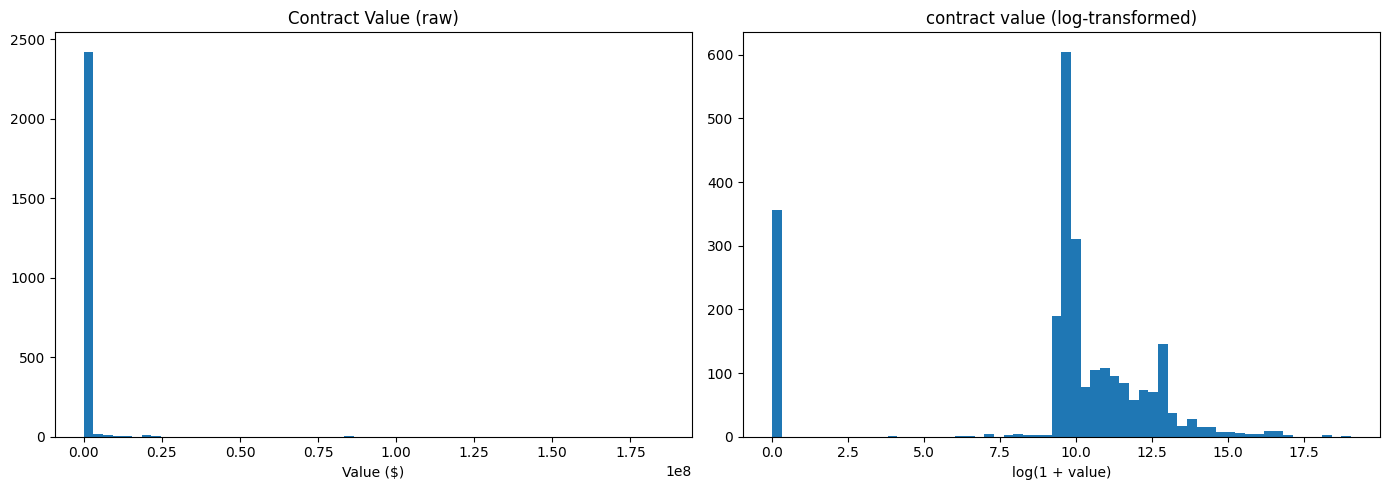

,contract_value
count,2.470000e+03
mean,4.500868e+05
std,4.754173e+06
min,0.000000e+00
25%,1.379700e+04
50%,1.993099e+04
75%,8.635523e+04
max,1.854247e+08


In [13]:
# value distribution plot:
n_nonpositive = (df['contract_value'] <= 0).sum()
print(f"Contracts with value <= 0: {n_nonpositive} ({n_nonpositive/len(df):.1%})")
df['log_contract_value'] = np.log1p(df['contract_value'].clip(lower=0))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['contract_value'], bins=60)
axes[0].set_title('Contract Value (raw)')
axes[0].set_xlabel('Value ($)')
axes[1].hist(df['log_contract_value'], bins=60)
axes[1].set_title('contract value (log-transformed)')
axes[1].set_xlabel('log(1 + value)')
plt.tight_layout()
plt.show()
df['contract_value'].describe()

### Contract values

These seem to be all over the place, which I would expect for this type of data. The plot is extremely right skewed. Half of the copntracts are worth less than 20k, a few massive ones are up to 185million. This drags the avg to 450k. That avg is much more than the typical contract which shows how the few outliers skews the numbers

If the values are plotted on a log scale, most of the contracts fall into a normal looking range between 10k and 500k. There is also a noticable cluster sitting at -. Those are probably from adjustments or contracts that were entered before a final dollar amount was set.

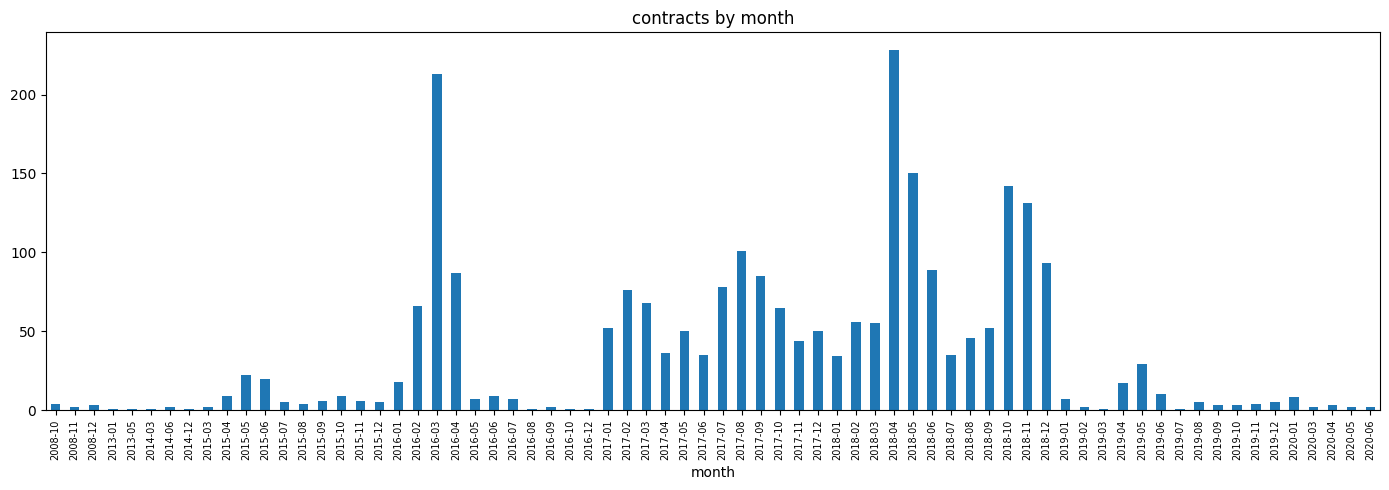

In [14]:
# contracts by month
fig, ax = plt.subplots(figsize=(14, 5))
df['contract_date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title('contracts by month')
ax.set_xlabel('month')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

contract_month
1     120
2     200
3     342
4     380
5     261
6     167
7     126
8     157
9     148
10    224
11    187
12    158
Name: count, dtype: int64


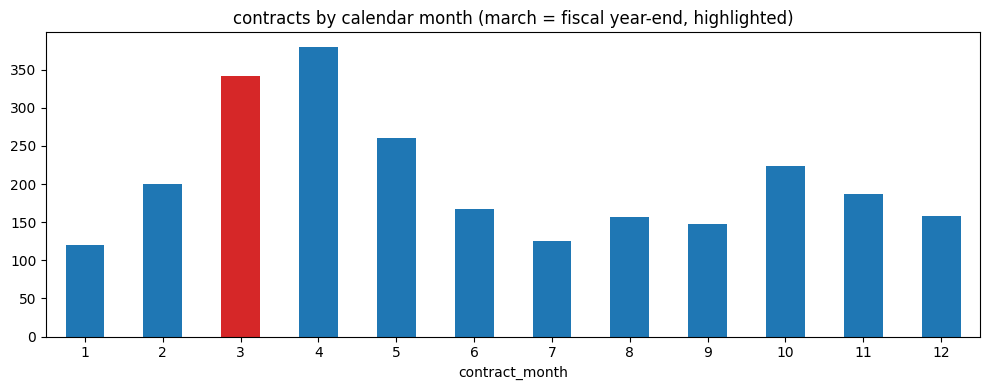


contracts in march/april (fiscal year boundary): 722 (29.2%)


In [15]:
# calendar month ditribution, fiscal yr end highlighted
df['contract_month'] = df['contract_date'].dt.month
month_counts = df['contract_month'].value_counts().sort_index()
print(month_counts)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#d62728' if m == 3 else '#1f77b4' for m in month_counts.index]
month_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('contracts by calendar month (march = fiscal year-end, highlighted)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
df['is_fiscal_year_end'] = df['contract_date'].dt.month.isin([3, 4])
print(f"\ncontracts in march/april (fiscal year boundary): {df['is_fiscal_year_end'].sum()} "
      f"({df['is_fiscal_year_end'].mean():.1%})")

### Fiscal year in contract dates
The data actually doesnt match what the brief expected - March (which is the fiscal yr end) has 342 contracts but april actually has more. This might be because April 1st is the start of the new fiscal year so a lot of contracts might get launched then. The spike at march is likely some type of a fiscal yr boundary effect.

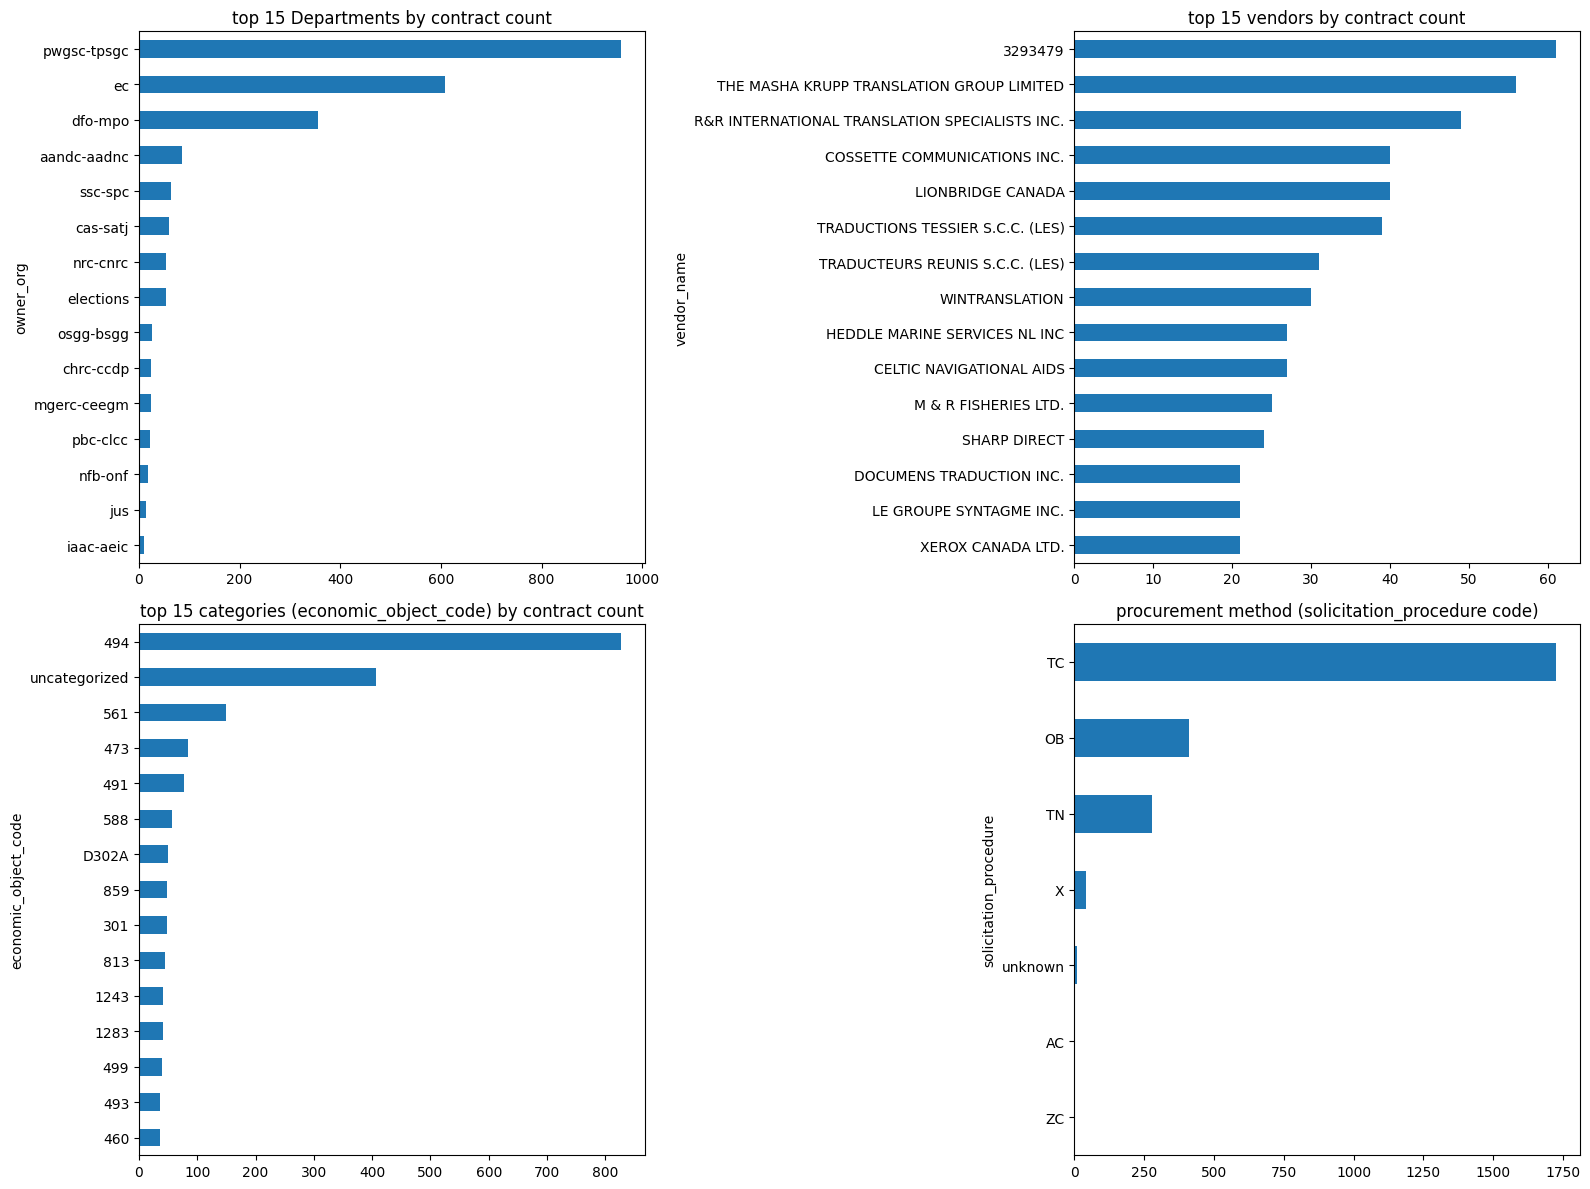

owner_org: top value = 'pwgsc-tpsgc', share of total = 38.7%, n_unique = 37
vendor_name: top value = '3293479', share of total = 2.5%, n_unique = 990
economic_object_code: top value = '494', share of total = 33.4%, n_unique = 135
solicitation_procedure: top value = 'TC', share of total = 69.8%, n_unique = 7


In [16]:
# counts bt department, vendor, category, and procurement method
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df['owner_org'].value_counts().head(15).plot(kind='barh', ax=axes[0,0])
axes[0,0].set_title('top 15 Departments by contract count')
axes[0,0].invert_yaxis()
df['vendor_name'].value_counts().head(15).plot(kind='barh', ax=axes[0,1])
axes[0,1].set_title('top 15 vendors by contract count')
axes[0,1].invert_yaxis()
df['economic_object_code'].value_counts().head(15).plot(kind='barh', ax=axes[1,0])
axes[1,0].set_title('top 15 categories (economic_object_code) by contract count')
axes[1,0].invert_yaxis()
df['solicitation_procedure'].value_counts().plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('procurement method (solicitation_procedure code)')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()
for col in ['owner_org', 'vendor_name', 'economic_object_code', 'solicitation_procedure']:
    vc = df[col].value_counts(normalize=True)
    print(f"{col}: top value = {vc.index[0]!r}, share of total = {vc.iloc[0]:.1%}, "
          f"n_unique = {df[col].nunique()}")

In [17]:
# mapping solicitation_procedure codes to sole-source vs competitive
procedure_map = {
    'OB': 'competitive',
    'TC': 'competitive',
    'ST': 'competitive',
    'TN': 'non_competitive',
    'AC': 'non_competitive',
}
df['procurement_category'] = df['solicitation_procedure'].map(procedure_map).fillna('other_unspecified')

print(df['procurement_category'].value_counts())
print(df['procurement_category'].value_counts(normalize=True))

procurement_category
competitive          2136
non_competitive       282
other_unspecified      52
Name: count, dtype: int64
procurement_category
competitive          0.864777
non_competitive      0.114170
other_unspecified    0.021053
Name: proportion, dtype: float64


### Counts by Column

**Departments**

Public works and Government Services Canada dominates with 957 contracts. Environment Canada (608 contracts) and Fisheries and Oceans (356 contracts) make up the top three. The smaller departments near the bottom only have a handful each so any stats wwithin those departments themselves probably wont be that reliable.

**Vendors**

The top vendor is a numeric id instead of an actual company. I looked this up and that number is the product manufacturer number for the Vulcan TTH1314 Back Saw, and serves as a business registry number for Canadian government databases.
Translation vendors show repeatedly near the top which lines up with "Translation services" being the most common contract description

**Categories**

Code 494 (Translation services) alon makes up 826 out of the 2470 contracts. The second biggest bucket is 'uncategorized' which makes up 407 cibtracts.

**Procurment method**

Competitive non-GETS contracts (TC) make up 70% of everything. This is followed by OB (competitive through GETS). TN (non-competitive contracts) are a big chunk too at around 11%. The remaining methods are more rare.


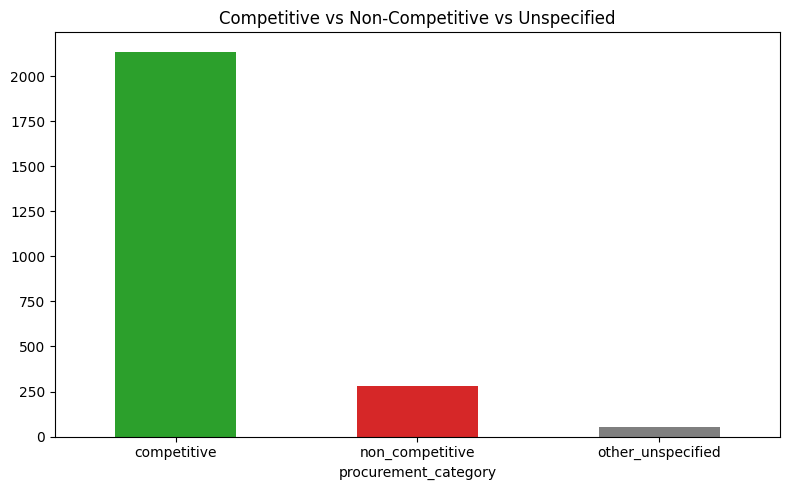

In [18]:
# breaking down competitive vs non-competitive
fig, ax = plt.subplots(figsize=(8, 5))
df['procurement_category'].value_counts().plot(
    kind='bar', ax=ax, color=['#2ca02c', '#d62728', '#7f7f7f'])
ax.set_title('Competitive vs Non-Competitive vs Unspecified')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# sole source rate by department
df['is_sole_source'] = df['procurement_category'] == 'non_competitive'

sole_source_by_dept = df.groupby('owner_org')['is_sole_source'].agg(
    sole_source_rate='mean', total_contracts='count'
).sort_values('sole_source_rate', ascending=False)

# Filter to departments with enough volume to be meaningful
display(sole_source_by_dept[sole_source_by_dept['total_contracts'] >= 10].head(15))

,sole_source_rate,total_contracts
owner_org,,
nfb-onf,1.000000,19
iaac-aeic,0.600000,10
pbc-clcc,0.545455,22
chrc-ccdp,0.500000,24
aandc-aadnc,0.488372,86
cas-satj,0.416667,60
osgg-bsgg,0.280000,25
nrc-cnrc,0.240741,54
jus,0.214286,14


### Sole-source vs competitive

Using the oddicial codes, procurement breaks down to more than 80 % competitive, around 10% non-competitive/sole sorce, and the remaining tiny percentage as unspecified. Looking at the sole source rates by department showed something interesting for the audit. The National Film Board is 100% sole source more than half the time. This is way above the 10%~ average and much higher than PWGSC's 5%~. This could be explained by it being Cnadas central procurement authority and them mostly running competitive processes.

Contracts amended: 2282 of 2470 (92.4%)


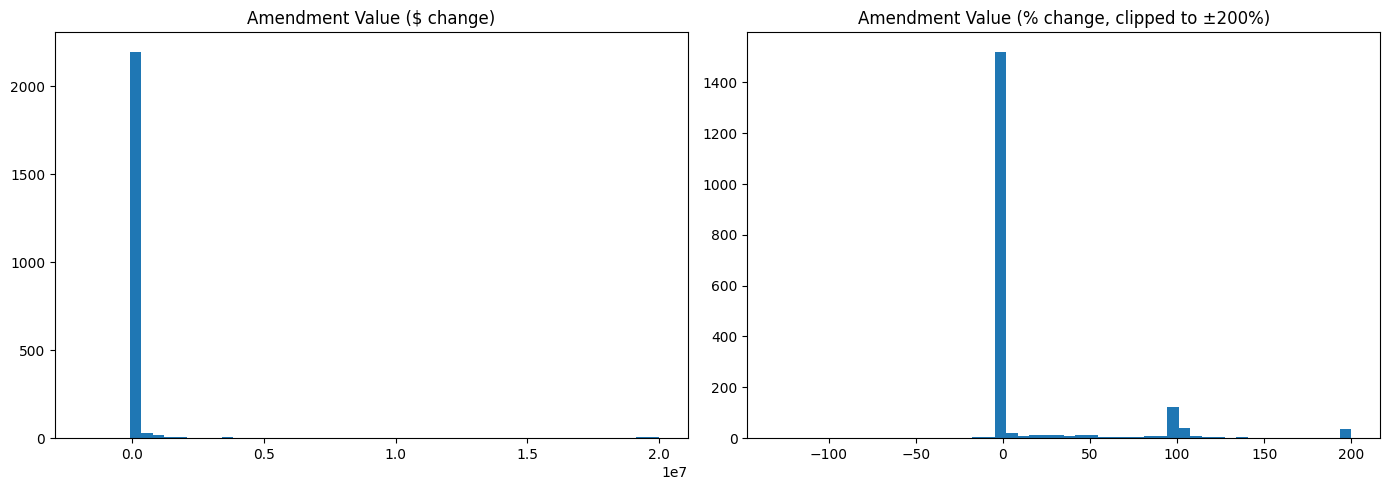

,amendment_value,amendment_pct_change
count,2.282000e+03,1.898000e+03
mean,1.541868e+05,2.881729e+05
std,1.372623e+06,1.250220e+07
min,-1.858285e+06,-1.302662e+02
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00
max,2.000000e+07,5.446680e+08


In [20]:
# plotting amendment frequency and value impact
print(f"Contracts amended: {df['was_amended'].sum()} of {len(df)} ({df['was_amended'].mean():.1%})")

amended = df[df['was_amended'] == 1].copy()
amended['amendment_pct_change'] = (
    amended['amendment_value'] / amended['original_value'].replace(0, np.nan)
) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(amended['amendment_value'], bins=50)
axes[0].set_title('Amendment Value ($ change)')

axes[1].hist(amended['amendment_pct_change'].clip(-200, 200), bins=50)
axes[1].set_title('Amendment Value (% change, clipped to ±200%)')

plt.tight_layout()
plt.show()

amended[['amendment_value', 'amendment_pct_change']].describe()

In [21]:
display(
    amended.nlargest(10, 'amendment_pct_change')[
        ['reference_number', 'vendor_name', 'original_value', 'amendment_value', 'amendment_pct_change']
    ]
)

,reference_number,vendor_name,original_value,amendment_value,amendment_pct_change
1252,1920512292,ALTIS HR,0.01,54466.80,5.446680e+08
1251,1908172290,TBP & ASSOCIATES INC.,1.13,25423.87,2.249900e+06
1887,C-2017-2018-Q4-02181,"SPAR ASSOCIATES, INC",100000.00,846999.79,8.469998e+02
1036,C-2017-2018-Q2-00587,EXCEL HUMAN RESOURCES INC.,34105.50,174152.64,5.106292e+02
644,C-2018-2019-Q1-00650,MAPLESOFT GROUP,18373.01,91865.03,4.999999e+02
1372,C-2017-2018-Q2-00020,IBISKA,52500.00,215502.30,4.104806e+02
626,C-2018-2019-Q1-00645,EXCEL HUMAN RESOURCES INC.,34105.50,113973.23,3.341784e+02
2431,C-2019-2020-Q3-00124,TEKSYSTEMS CANADA INC.,252340.00,839604.00,3.327273e+02
2433,C-2019-2020-Q3-00123,MAPLESOFT CONSULTING INC.,217580.00,723948.00,3.327273e+02
974,C-2017-2018-Q1-00063,CAPITAL DEDICATED LOGISTICS INC,47188.02,148697.17,3.151164e+02


### Amendment rate

From a first look, majority of the contracts show up as amended, meaning that the amendment_value is not null. This is really really high. The dataset notes mention that the amendment values are only for Q1 which means this field could capture one reporting periods amendments (and not its whole history)

After skimming the dataset, most of the contrracts with an actual value change, show 0$ or a 0% change. This means amended typically just means a contract got touched during the amendment reporting cycle and not that the proce actually moved.

The real outliers are super obvious here. ALTIS HR contract jumped from 0.01$ to around 54k after amendment. This is a massive increase thats probably a placeholder value getting corrected and not actually an irregularity in the spending. This would be an example of what the tool should flag as 'unusual'

Other than that there seems to be a genuine clister of contracts amended to a reasonable amount (3x or 5x their value). These are good candidates for building an amendment_pct_change feature for peer comparison.

## Progress Report
So far I've cleaned the contracts dataset, dropping empty columns, fixing data types, and handling missing values. I built the core logic for comparing each contract's value against similar contracts in the same department and category, which flags unusual ones with a plain-English reason. I also ran the exploratory analysis on value distributions, dates, departments, vendors, and amendments, and found some real patterns to build on, like certain departments using sole source contracts far more than others, and a large chunk of contracts still missing a category.


## Client Feedback:

1. for  '"short ranked list" is there a specific number of contracts you want flagged?

no fixed number, i’d rather flag a small manageable percentage of the highest priority contracts as the top 1-5%, depending on dataset size.

2. is a fixed short ranked list (like top 20) the right output, or should the number of flagged contracts scale with how much data there is?

scale it with the amount of data,  fixed top 20 could be too few for a large dataset or too many for a small one, need a practical shortlist auditors could realistically review


3. should outliers be based on dollar value alone, or do you want date/timing patterns (like end of year spending spikes) factored in too?

nope, not dollar value alone. include other unusual patterns too- timing, amendments, supplier behaviour, procurement method how the value compares with similar contracts- a high  value contract by itself should not automatically be treated as suspicious


## Analyze and Justify: Supervised vs. Unsupervised

The problem statement has three different sub problems and each require a differnt approach. The technique I pick would depend on whether a solid label exists to predict.

1. First Problem - Numeric irregularity detection (price/date/dept/vendor vs. peers): **This should be unsupervised**. The client stated in the proposal that no confirmed fraud cases are in the data. So, there is nothing to predict toward. So this is pattern discovery and not prediction

2. Second Problem (first part) - Spending theme grouping: **This is also unsupervised**. The success criteria for this asks for themes to be discovered and not predicted from a known list. There is no existing target, so clustering the description text would likely be a good way to tackle this one.

3. Second Problem (second part) - Description vs. category consistency check: **This would be supervised.** A real label already exists for this part (economic_object_code), and this is populated for around 90% of the contracts. So here, checking whther the free text descriptions are consistent with their assigned code is multi-class text classification problem with tangible proof.


## Problem 1: Numeric Irregularity

forgot to push changes from other device... updating this with my old markdown on there later today

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html



In [23]:
# feature engineering
df['amendment_pct_change'] = np.where(
    df['original_value'].replace(0, np.nan).notna(),
    (df['amendment_value'] / df['original_value'].replace(0, np.nan)) * 100, 0).clip(-500, 500)
df['days_to_delivery'] = (df['delivery_date'] - df['contract_date']).dt.days
df['days_to_delivery'] =df['days_to_delivery'].fillna(df['days_to_delivery'].median())

for col in ['owner_org', 'vendor_name', 'economic_object_code']:
    df[f'{col}_freq']=df[col].map(df[col].value_counts(normalize=True))
feature_cols = [
    'log_contract_value', 'amendment_pct_change', 'was_amended', 'is_sole_source',
    'days_to_delivery', 'contract_month', 'owner_org_freq', 'vendor_name_freq',
    'economic_object_code_freq']

X = df[feature_cols].fillna(0)
iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
df['anomaly_flag'] = iso.fit_predict(X)
df['anomaly_score']= iso.decision_function(X)

n_flagged = (df['anomaly_flag'] == -1).sum()
print(f"Flagged: {n_flagged} of {len(df)} ({n_flagged/len(df):.1%})")
df.nsmallest(10, 'anomaly_score')[['reference_number','owner_org','vendor_name',
    'contract_value','amendment_pct_change','is_sole_source','anomaly_score']]

Flagged: 124 of 2470 (5.0%)


,reference_number,owner_org,vendor_name,contract_value,amendment_pct_change,is_sole_source,anomaly_score
1411,NO15-SC019,pbc-clcc,Centre for Excellence in Communications,10068.30,0.000000,True,-0.053147
1402,NO15-CU007,pbc-clcc,Neopost Canada Limited,24329.35,0.000000,False,-0.052634
1416,PA15-SC001,pbc-clcc,The Retirement Planning Institute,16065.00,0.000000,True,-0.050874
1887,C-2017-2018-Q4-02181,pwgsc-tpsgc,"SPAR ASSOCIATES, INC",1617708.76,500.000000,False,-0.050095
1278,C-2015-2016-Q3-00026,mgerc-ceegm,FULLVIEW DESIGN,51.60,0.000000,True,-0.050028
1401,NO15-CU006,pbc-clcc,Xerox Canada Ltd.,14881.37,0.000000,False,-0.046333
2433,C-2019-2020-Q3-00123,ssc-spc,MAPLESOFT CONSULTING INC.,941528.00,332.727273,False,-0.044943
2431,C-2019-2020-Q3-00124,ssc-spc,TEKSYSTEMS CANADA INC.,1091944.00,332.727273,False,-0.044914
1412,QU15-SC001,pbc-clcc,Wanda Gabriel,12500.00,0.000000,True,-0.044445
153,P1700035,chrc-ccdp,Bell Canada,92208.00,0.000000,True,-0.044012


### Problem 1: Analysis #1
forgot to push changes from other device... updating this with my old markdown on there later today

## Problem 2: Spending Theme Grouping

forgot to push changes from other device... updating this with my old markdown on there later today



In [25]:
text_df = df[df['description_en'].notna()].copy()
vectorizer = TfidfVectorizer(stop_words='english', max_features=1500, min_df=3, ngram_range=(1,2))
X_text=vectorizer.fit_transform(text_df['description_en'])
scores ={}
for k in [5, 8, 10, 12, 15, 20]:
    labels=KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_text)
    scores[k] =silhouette_score(X_text, labels, sample_size=1000, random_state=42)
    print(f"k={k}: silhouette={scores[k]:.3f}")

k=5: silhouette=0.489
k=8: silhouette=0.567
k=10: silhouette=0.609
k=12: silhouette=0.639
k=15: silhouette=0.666
k=20: silhouette=0.718


### Problem 2: Analysis #1

As k went up, the silhoette score kept climbing too. It went from .489 at k=5, all the way up to .718 at k=20. After looking into this a bit online, I learned that this is known to happen with sparse TF-IDF text vectors. So, adding more clusters will squeeze out a bit more separation.

If I pick k based purely on highest silhouette score, Id be picking k=20. But this produces really narrow categores that wouldnt really be useful to an auditor.

While silhouette score has helped to explore a bit, I think k=12 is a good middle ground to tell the categories apart without making it difficult for an auditor to filter through.

In [26]:
k =12
km_final =KMeans(n_clusters=k, random_state=42, n_init=10)
text_df['spending_theme_cluster'] = km_final.fit_predict(X_text)
terms= vectorizer.get_feature_names_out()
centers =km_final.cluster_centers_
cluster_labels ={}
for c in range(k):
    top_idx = centers[c].argsort()[-6:][::-1]
    cluster_labels[c] = ', '.join(terms[i] for i in top_idx[:3])
    print(f"Cluster {c} (n={sum(text_df['spending_theme_cluster']==c)}): {cluster_labels[c]}")
text_df['spending_theme_label'] = text_df['spending_theme_cluster'].map(cluster_labels)

Cluster 0 (n=82): information, information technology, technology
Cluster 1 (n=470): translation, translation services, services
Cluster 2 (n=357): operating expenses, serv operating, transl
Cluster 3 (n=76): consulting, management consulting, management
Cluster 4 (n=503): services, scientific, consultants
Cluster 5 (n=141): professional services, professional, services specified
Cluster 6 (n=154): aircraft, rental aircraft, rental
Cluster 7 (n=33): protection services, protection, services
Cluster 8 (n=52): help, temporary, temporary help
Cluster 9 (n=48): advertising, advertising services, services
Cluster 10 (n=161): computer, equipment, desktop
Cluster 11 (n=37): interpretation, interpretation services, services


### Problem 2: Analysis #2


What I see here, is that the clusters line up really cleany with recognizable spending categories. Each cluster is dominated by a single existing accounting code. This confirms these clusters reflect meaningfuk groups instead of noise.

This works really well for what my client asked for.

They wanted readable, plain-language theme labels and not numeric codes(ex. an example they gave way 'cloud infastructure')

This gives auditors a way to browse and filter through contracts by what was actually bought, as opposed to having to decode it from an accounting number.

## Problem 3: Description vs Category Check

This part is where the real labels can be used. I can also utilize the economic_object_code column which has about 90% of the contracts filled in.

I now also have a clear testable question which is:  based on the descript text alone, what category would a contract fall into.

Comparing the prediction from this to the category the contract was actially assigned to, gives me a solid way to spot incosistencies.

This is exactly what my client's second requirement is asking for (a way to check if the contract description matches its category).

In [29]:
labeled = df[(df['economic_object_code'] != 'uncategorized') & (df['description_en'].notna())].copy()
# categories with less than 15 examples are too sparse to train &evaluate reliably
# therefore I excluded them instead of keeping
category_counts = labeled['economic_object_code'].value_counts()
valid_categories = category_counts[category_counts >= 15].index
model_df = labeled[labeled['economic_object_code'].isin(valid_categories)].copy()
print(f"modeled: {len(model_df)} of {len(labeled)} labeled contracts "
      f"({len(valid_categories)} categories with >=15 examples)")

X_train, X_test, y_train, y_test = train_test_split(
    model_df['description_en'], model_df['economic_object_code'],
    test_size=0.25, random_state=42, stratify=model_df['economic_object_code'])
vectorizer = TfidfVectorizer(stop_words='english', max_features=2000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)
print(f"accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"macro F1: {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"weighted F1: {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(classification_report(y_test, y_pred, zero_division=0))

modeled: 1738 of 2063 labeled contracts (22 categories with >=15 examples)
accuracy: 0.989
macro F1: 0.977
weighted F1: 0.989
              precision    recall  f1-score   support

        1139       1.00      1.00      1.00         4
        1179       1.00      1.00      1.00         4
        1243       1.00      1.00      1.00        11
        1261       0.83      1.00      0.91         5
        1283       0.90      0.90      0.90        10
         301       1.00      1.00      1.00        12
         332       1.00      1.00      1.00         5
         351       1.00      1.00      1.00         7
         430       1.00      1.00      1.00         5
         431       1.00      1.00      1.00         4
         447       1.00      0.83      0.91         6
         460       1.00      1.00      1.00         9
         473       1.00      0.95      0.98        21
         491       1.00      1.00      1.00        19
         493       1.00      1.00      1.00         9
         